## **1. Projeto de Machine Learning I 2025/2026: Avaliação e Adaptação de Algoritmos de Classificação**

**Universidade do Porto (U. PORTO)** **Unidade Curricular:** Machine Learning I (CC2008)  
**Turma:** PL3 | **Grupo:** PL3_G1  
**Docente:** Rita Paula Almeida Ribeiro  

### **Equipa de Desenvolvimento**
| Número | Nome |
| :--- | :--- |
| **202300276** | Guilherme Klippel |
| **202512256** | Lucas Coelho |
| **202304280** | Daniel Tiago |

---

### **Introdução e Contexto do Problema**
A nossa abordagem divide-se nas duas fases exigidas pelo projeto:
1. **Fase 1 (Baseline):** Implementação do algoritmo padrão, preparação de uma *pipeline* robusta de dados e avaliação do seu desempenho inicial (*benchmarking*) perante os *datasets* fornecidos.
2. **Fase 2 (Proposta de Melhoria):** Proposição, implementação e avaliação empírica de uma variante do algoritmo desenhada especificamente para lidar de forma mais eficiente com os problemas intrínsecos à classificação de múltiplas classes, comparando os resultados com a versão original.

##### Importes 

In [1]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2
import os
import time
import numpy as np
import pandas as pd
from IPython.display import display 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report
)
from src.logistic_regression import LogisticRegression

## 1. Tratamento da Baseline e Pré-Processamento

In [2]:
exemplo_path = r"E:\FCUP\AC1\Projeto\datasets\multiclass_classification\dataset_381_ipums_la_98-small.csv"

# Carregar Dados
df_exemplo = pd.read_csv(exemplo_path)
X_df = df_exemplo.iloc[:, :-1].copy()
y_df = df_exemplo.iloc[:, -1].copy()

# 1. Informações Estruturais
print(f"Dimensões originais - Amostras(Linhas): {X_df.shape[0]}, Features(Colunas): {X_df.shape[1]}")
print(f"Total de valores nulos (NaN): {X_df.isnull().sum().sum()}")

# 2. Análise dos Tipos de Dados
tipos_dados = X_df.dtypes.value_counts()
for tipo, contagem in tipos_dados.items():
    print(f"- {tipo}: {contagem} coluna(s)")

# 3. Verificação do Target (y)
print(f"Tipo de dado do Target (y): {y_df.dtype}")

Dimensões originais - Amostras(Linhas): 7485, Features(Colunas): 60
Total de valores nulos (NaN): 52048
- int64: 34 coluna(s)
- object: 26 coluna(s)
Tipo de dado do Target (y): int64



### Tratamento dos Valores Nulos
* Variáveis Numéricas (Imputação pela Mediana)

O que fizemos: Substituímos os valores nulos pelo valor central da coluna (a mediana).

Por quê: Ao contrário da média, a mediana é robusta a outliers (valores extremos). Em um dataset real, onde podem existir ruídos ou valores atípicos, a média pode ser "puxada" para longe da realidade, enquanto a mediana mantém a representatividade estatística da maioria dos dados.

* Variáveis Categóricas ou de Texto (Imputação pela Moda)

O que fizemos: Substituímos os valores nulos (NaNs) pelo valor que mais se repete na coluna (a moda).

Por quê: Para dados do tipo texto (strings ou objects), não é possível realizar operações matemáticas. A moda é a escolha mais lógica para manter a consistência categórica, partindo da premissa de que a falta de um dado tem maior probabilidade de pertencer à classe mais comum daquela coluna.

In [3]:
def imputar_nulos(df):
    """
    Função pura que substitui NaNs pela mediana (numéricos) ou moda (categóricos).
    Retorna o DataFrame limpo e os índices das linhas que foram alteradas.
    """
    df_clean = df.copy()
    indices_nulos = df_clean[df_clean.isnull().any(axis=1)].index
    
    cols_num = df_clean.select_dtypes(include=[np.number]).columns
    cols_cat = df_clean.select_dtypes(exclude=[np.number]).columns
    
    if len(cols_num) > 0:
        df_clean[cols_num] = df_clean[cols_num].fillna(df_clean[cols_num].median())
        
    for col in cols_cat:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            
    return df_clean, indices_nulos

##### Exemplo Prático

In [4]:
# 1. Chamar a função usando o X_df que já está na memória
X_limpo, linhas_alteradas = imputar_nulos(X_df)

# 2. Imprimir os resultados e analisar (EDA)
print(f"Total de NaNs ANTES da limpeza: {X_df.isnull().sum().sum()}")
print(f"Total de NaNs DEPOIS da limpeza: {X_limpo.isnull().sum().sum()}")

if len(linhas_alteradas) > 0:
    print("\n--- ANTES da limpeza (As linhas que tinham NaNs): ---")
    # Mostra o X_df original
    display(X_df.loc[linhas_alteradas].head(5))
    
    print("\n--- DEPOIS da limpeza (As mesmas linhas corrigidas): ---")
    # Mostra o X_limpo
    display(X_limpo.loc[linhas_alteradas].head(5))
else:
    print("\nO dataset não tinha valores nulos.")

Total de NaNs ANTES da limpeza: 52048
Total de NaNs DEPOIS da limpeza: 0

--- ANTES da limpeza (As linhas que tinham NaNs): ---


,year,gq,gqtypeg,farm,ownershg,value,rent,ftotinc,nfams,ncouples,...,incbus,incfarm,incss,incwelfr,incother,poverty,migrat5g,migplac5,vetstat,tranwork
0,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,325,9505,1,1,...,0,0,0,0,0,128,Same_state_countydifferent_house,California,No_Service,NaN
1,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,287,8005,1,0,...,0,0,0,0,0,211,NaN,NaN,No_Service,NaN
2,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),85000,0,29635,1,1,...,999999,999999,99999,99999,99999,304,NaN,NaN,NaN,NaN
3,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),999999,0,52895,1,1,...,0,0,0,0,0,501,Same_house,Same_house,No_Service,NaN
4,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,185,7610,2,0,...,0,0,0,0,0,119,NaN,NaN,No_Service,Auto



--- DEPOIS da limpeza (As mesmas linhas corrigidas): ---


,year,gq,gqtypeg,farm,ownershg,value,rent,ftotinc,nfams,ncouples,...,incbus,incfarm,incss,incwelfr,incother,poverty,migrat5g,migplac5,vetstat,tranwork
0,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,325,9505,1,1,...,0,0,0,0,0,128,Same_state_countydifferent_house,California,No_Service,Auto
1,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,287,8005,1,0,...,0,0,0,0,0,211,Same_house,Same_house,No_Service,Auto
2,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),85000,0,29635,1,1,...,999999,999999,99999,99999,99999,304,Same_house,Same_house,No_Service,Auto
3,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),999999,0,52895,1,1,...,0,0,0,0,0,501,Same_house,Same_house,No_Service,Auto
4,98,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,999999,185,7610,2,0,...,0,0,0,0,0,119,Same_house,Same_house,No_Service,Auto


### Conversão de Texto para Números (One-Hot Encoding)
O nosso algoritmo matemático não compreende *strings* (variáveis do tipo `object`). Para resolver isto, aplicamos a técnica de **One-Hot Encoding** usando a função `get_dummies` do pandas.

* O que faz: Cria uma nova coluna binária (0 ou 1) para cada categoria de texto.
* Prevenção de Colinearidade: Utilizamos o parâmetro `drop_first=True` para evitar a "Armadilha das Variáveis Dummy" (*Dummy Variable Trap*), garantindo que as novas colunas não sejam perfeitamente correlacionadas, o que desestabilizaria o modelo matemático.

In [5]:
def aplicar_encoding(X_df, y_df):
    """
    Função pura: Aplica One-Hot Encoding nas features categóricas (X) e
    converte a variável alvo (y) para numérico. 
    Retorna o DataFrame transformado, as matrizes Numpy e as colunas originais.
    """
    X_clean = X_df.copy()
    y_clean = y_df.copy()
    
    # 1. Identificar as colunas de texto
    cols_cat = X_clean.select_dtypes(exclude=[np.number]).columns
    
    # 2. Aplicar o Encoding
    if len(cols_cat) > 0:
        X_clean = pd.get_dummies(X_clean, columns=cols_cat, drop_first=True)
    
    # 3. Converter tudo para Float (necessário para o Gradient Descent)
    X_clean = X_clean.astype(float)
    X_numpy = X_clean.values
    
    # 4. Tratar a variável alvo (y)
    if y_clean.dtype == 'object':
        y_numpy = pd.factorize(y_clean)[0]
    else:
        y_numpy = y_clean.values
        
    return X_clean, X_numpy, y_numpy, cols_cat

##### Exemplo Prático

In [6]:
# --- 1. Ver o ANTES ---
cols_cat = X_limpo.select_dtypes(exclude=[np.number]).columns
if len(cols_cat) > 0:
    print("--- ANTES do One-Hot Encoding (Apenas as colunas de texto) ---")
    display(X_limpo[cols_cat].head(5))
else:
    print("--- Não foram encontradas colunas de texto neste dataset. ---")

print(f"\nNúmero de colunas originais: {X_limpo.shape[1]}")

# --- 2. Executar a função ---
# Passamos o X_limpo e o y_df (que carregaste na 1ª célula do Notebook)
X_df_encoded, X_numpy, y_numpy, colunas_cat = aplicar_encoding(X_limpo, y_df)

# --- 3. Ver o DEPOIS ---
print(f"\n--- DEPOIS do One-Hot Encoding ---")
print(f"O número de features (colunas) saltou para {X_df_encoded.shape[1]}!")
print("Como o dataset numérico ficou agora:")
display(X_df_encoded.head(5))

# As variáveis finais prontas para o modelo são 'X_numpy' e 'y_numpy'

--- ANTES do One-Hot Encoding (Apenas as colunas de texto) ---


,gq,gqtypeg,farm,ownershg,relateg,sex,raceg,marst,chborn,bplg,...,ind1950,classwkg,wkswork2,hrswork2,yrlastwk,workedyr,migrat5g,migplac5,vetstat,tranwork
0,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Spouse,Female,White,Married_spouse_present,2__children,California,...,Food_stores_except_dairy,Works_for_wages_salary,50-52_weeks,40_hours,Worked_3-5_yrs_ago,No,Same_state_countydifferent_house,California,No_Service,Auto
1,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Head_Householder,Female,Black_Negro,Never_married_single,No_children,California,...,Crude_petroleum_and_natural_gas_extraction,Works_for_wages_salary,40-47_weeks,40_hours,Worked_current_yr,Yes,Same_house,Same_house,No_Service,Auto
2,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),Child,Female,White,Never_married_single,No_children,California,...,Educational_services,Works_for_wages_salary,50-52_weeks,40_hours,Worked_more_than_10_yrs_ago,Yes,Same_house,Same_house,No_Service,Auto
3,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Owned_or_being_bought_(loan),Child,Male,White,Never_married_single,No_children,California,...,Educational_services,Works_for_wages_salary,50-52_weeks,40_hours,Never_worked,No,Same_house,Same_house,No_Service,Auto
4,HH_in_1970_definition_but_sampled_as_larger_unit,NA_(household),Non-Farm,Rented,Partner_friend_visitor,Female,White,Never_married_single,No_children,California,...,Hospitals,Works_for_wages_salary,40-47_weeks,15-29_hours,Worked_more_than_10_yrs_ago,Yes,Same_house,Same_house,No_Service,Auto



Número de colunas originais: 60

--- DEPOIS do One-Hot Encoding ---
O número de features (colunas) saltou para 596!
Como o dataset numérico ficou agora:


,year,value,rent,ftotinc,nfams,ncouples,nmothers,nfathers,momloc,stepmom,...,vetstat_Yes,tranwork_Bicycle,tranwork_Bus_or_streetcar,tranwork_Motorcycle,tranwork_Other,tranwork_Taxicab,tranwork_Truck,tranwork_Van,tranwork_Walked_only,tranwork_Worked_at_home
0,98.0,999999.0,325.0,9505.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,98.0,999999.0,287.0,8005.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,98.0,85000.0,0.0,29635.0,1.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,98.0,999999.0,0.0,52895.0,1.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,98.0,999999.0,185.0,7610.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Normalização
Aplicamos a normalização Z-Score para colocar todas as variáveis numéricas na mesma escala matemática (garantindo média igual a 0 e desvio padrão igual a 1). Isso impede que o algoritmo dê mais importância a uma variável apenas por ela ter valores absolutos maiores (como "Salário" vs "Idade").

In [7]:
def normalizar_zscore(X_train, X_test):
    """
    Aplica a escala Z-Score (StandardScaler).
    Retorna os dados escalados e os parâmetros estatísticos.
    """
    # 1. Calcular parâmetros APENAS no treino (evita Data Leakage)
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    
    # Prevenir divisão por zero caso uma feature seja constante
    sigma[sigma == 0] = 1e-8 
    
    # 2. Aplicar a transformação: z = (x - mu) / sigma
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma
    
    return X_train_s, X_test_s, mu, sigma


#### Exemplo Prático

In [8]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_numpy, y_numpy, test_size=0.3, stratify=y_numpy, random_state=42
)

print("--- ANTES da Normalização ---")
print(f"Média da 1ª feature: {np.mean(X_tr_raw[:, 0]):.2f}")
print(f"Desvio Padrão da 1ª feature: {np.std(X_tr_raw[:, 0]):.2f}")

# Chamamos a função (agora os dados são 100% numéricos)
X_train, X_test, mu, sigma = normalizar_zscore(X_tr_raw, X_te_raw)

print("\n--- DEPOIS da Normalização ---")
print(f"Média final: {np.mean(X_train[:, 0]):.10f}")
print(f"Desvio Padrão final: {np.std(X_train[:, 0]):.10f}")

--- ANTES da Normalização ---
Média da 1ª feature: 98.00
Desvio Padrão da 1ª feature: 0.00

--- DEPOIS da Normalização ---
Média final: 0.0000000000
Desvio Padrão final: 0.0000000000


### K-FOLD Cross-Validation
A função `avaliar_kfold` é o nosso "teste de estresse". Em vez de separar os dados apenas uma vez em treino e teste (o que poderia gerar um resultado de "sorte"), dividimos a base de dados em K pedaços (folds). O modelo treina em $K-1$ pedaços e faz a prova final no pedaço que sobrou, repetindo esse processo até que todos os pedaços tenham sido usados como teste.

In [9]:
def avaliar_kfold(X, y, n_splits=5, lr=0.01, max_iters=1000, random_state=42):
    """
    Função pura: Executa o K-Fold Cross-Validation com normalização local.
    Retorna o DataFrame de métricas, a lista de modelos treinados e os 
    dados da última iteração (para podermos desenhar gráficos depois).
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    modelos = []
    
    # Variáveis para guardar os dados do último fold (útil para os gráficos)
    X_te_last, y_te_last, y_pred_last = None, None, None

    for i, (train_idx, test_idx) in enumerate(kf.split(X)):
        # 1. Divisão
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # 2. Normalização Z-Score (USANDO A NOSSA FUNÇÃO)
        X_tr_s, X_te_s, mu, sigma = normalizar_zscore(X_tr, X_te)

        # 3. Treino
        model = LogisticRegression(lr=lr, max_iters=max_iters)
        model.fit(X_tr_s, y_tr)
        modelos.append(model)

        # 4. Previsão e Métricas
        y_pred = model.predict(X_te_s)
        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

        fold_results.append({
            'Fold': i + 1,
            'Accuracy': acc, 
            'Precision': prec, 
            'Recall': rec, 
            'F1-Score': f1
        })
        
        # Guardamos sempre os últimos dados processados
        X_te_last, y_te_last, y_pred_last = X_te_s, y_te, y_pred

    # Formatamos a tabela de resultados
    df_folds = pd.DataFrame(fold_results)
    df_folds.set_index('Fold', inplace=True)

    return df_folds, modelos, (X_te_last, y_te_last, y_pred_last)

#### Exemplo Prático

A treinar e avaliar o modelo base com 5-Folds. Por favor aguarda...

--- RESULTADOS DETALHADOS (FOLD A FOLD) ---


,Accuracy,Precision,Recall,F1-Score
Fold,,,,
1,0.579826,0.164325,0.249442,0.162740
2,0.573814,0.166322,0.242964,0.163728
3,0.580494,0.170377,0.248166,0.171160
4,0.575150,0.166532,0.242688,0.165301
5,0.567802,0.168172,0.247104,0.166387



--- PERFORMANCE CONSOLIDADA (Média e Desvio Padrão) ---


,Média (Final),Desvio Padrão
Accuracy,0.575418,0.005144
Precision,0.167146,0.002264
Recall,0.246073,0.003079
F1-Score,0.165863,0.003277


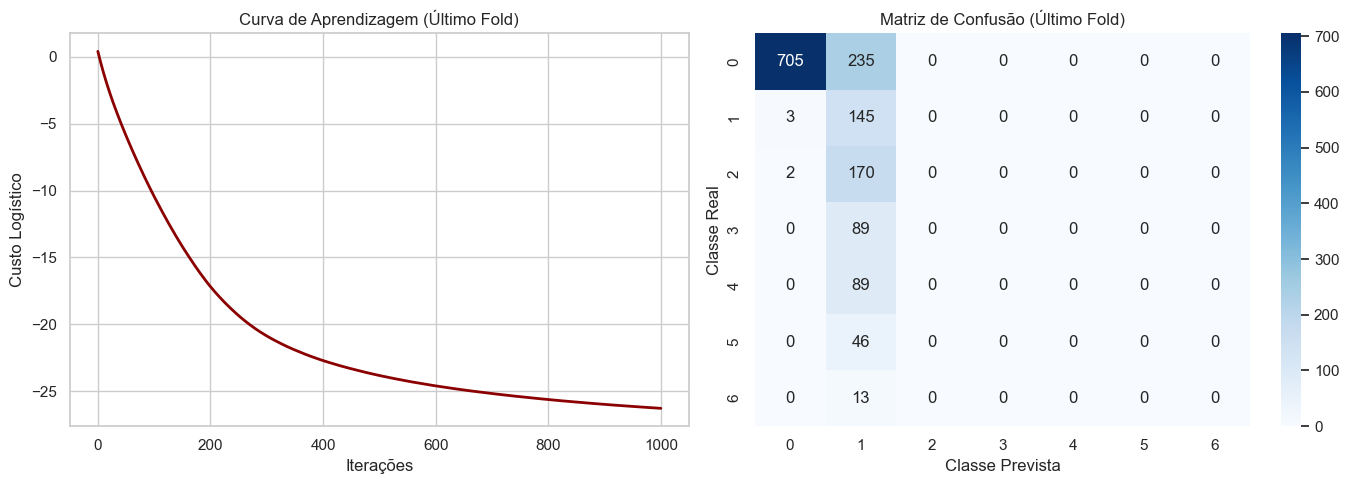

In [10]:
print("A treinar e avaliar o modelo base com 5-Folds. Por favor aguarda...\n")

# 1. Chamar a função pura (usando o X_numpy e y_numpy que saíram da célula de Encoding)
df_resultados_kf, modelos_treinados, ultimo_fold = avaliar_kfold(X_numpy, y_numpy, n_splits=5)
X_te_last, y_te_last, y_pred_last = ultimo_fold

# 2. Imprimir os resultados (Aqui estão os teus prints do K-Fold!)
print("--- RESULTADOS DETALHADOS (FOLD A FOLD) ---")
display(df_resultados_kf)

print("\n--- PERFORMANCE CONSOLIDADA (Média e Desvio Padrão) ---")
resumo = df_resultados_kf.agg(['mean', 'std']).T
resumo.columns = ['Média (Final)', 'Desvio Padrão']
display(resumo)

# 3. Visualização Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Curva de Aprendizagem do último modelo treinado
axes[0].plot(modelos_treinados[-1].errors, color='darkred', linewidth=2)
axes[0].set_title('Curva de Aprendizagem (Último Fold)')
axes[0].set_xlabel('Iterações')
axes[0].set_ylabel('Custo Logístico')
axes[0].grid(True)

# Gráfico B: Matriz de Confusão do último teste
cm = confusion_matrix(y_te_last, y_pred_last)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matriz de Confusão (Último Fold)')
axes[1].set_xlabel('Classe Prevista')
axes[1].set_ylabel('Classe Real')

plt.tight_layout()
plt.show()

### Treino, Inferência e Avaliação do Modelo Base
Com os dados limpos e a matriz $X$ perfeitamente padronizada, a matemática da nossa Regressão Logística construída de raiz já pode operar sem sofrer instabilidade (*overflow*).

Vamos instanciar o modelo, cronometrar o treino, calcular as métricas principais e avaliar o desempenho visualmente.

In [ ]:

pastas_datasets = {
    "grupo1_noise": "datasets/noise_outliers/",
    "grupo2_imbalance": "datasets/class_imbalance/",
    "grupo3_multiclass": "datasets/multiclass_classification/"
}

for grupo, path in pastas_datasets.items():
    if not os.path.exists(path):
        print(f"Aviso: Pasta '{path}' não encontrada. A saltar...")
        continue
        
    print(f"\n>>> PROCESSANDO: {grupo.upper()} <<<")
    resultados_grupo = []
    ficheiros = [f for f in os.listdir(path) if f.endswith('.csv')]

    for ficheiro in ficheiros:
        # Usamos end=" " para que o "OK!" ou "FALHOU" apareça na mesma linha do nome do ficheiro
        print(f"  - {ficheiro}...", end=" ") 
        
        meta = {
            'Dataset': ficheiro, 'N_Samples': 0, 'N_Features': 0,
            'Missing_Values': 0, 'Target_Classes': 0, 'Execution_Status': 'Error',
            'Accuracy': 0, 'Precision_Macro': 0, 'Recall_Macro': 0, 'F1_Macro': 0,
            'Training_Time_sec': 0
        }
        
        try:
            t_inicio = time.time()
            
            # 1. Carregar Dados
            df_full = pd.read_csv(os.path.join(path, ficheiro))
            X_orig = df_full.iloc[:, :-1]
            y_orig = df_full.iloc[:, -1]
            
            meta['N_Samples'] = X_orig.shape[0]
            meta['N_Features'] = X_orig.shape[1]
            meta['Missing_Values'] = X_orig.isnull().sum().sum()
            meta['Target_Classes'] = len(np.unique(y_orig))

            # =========================================================
            # A LINHA DE MONTAGEM (Usando as tuas funções puras!)
            # =========================================================
            
            # Passo A: Limpeza
            X_limpo, _ = imputar_nulos(X_orig)
            
            # Passo B: Encoding
            _, X_numpy, y_numpy, _ = aplicar_encoding(X_limpo, y_orig)
            
            # Passo C: K-Fold (A função faz o split, normaliza, treina e avalia)
            df_resultados_kf, _, _ = avaliar_kfold(X_numpy, y_numpy, n_splits=5)
            
            # =========================================================

            # Extrair as médias finais geradas pela nossa tabela de K-Fold
            meta['Execution_Status'] = 'Success'
            meta['Accuracy'] = df_resultados_kf['Accuracy'].mean()
            meta['Precision_Macro'] = df_resultados_kf['Precision'].mean()
            meta['Recall_Macro'] = df_resultados_kf['Recall'].mean()
            meta['F1_Macro'] = df_resultados_kf['F1-Score'].mean()
            
            meta['Training_Time_sec'] = time.time() - t_inicio
            
            print("OK!")

        except Exception as e:
            meta['Execution_Status'] = f"Error: {str(e)}"
            # Imprimimos o erro para saberes exatamente o que falhou se acontecer
            print(f"FALHOU ({str(e)})") 

        resultados_grupo.append(meta)

    # Exportar CSV do grupo
    if resultados_grupo:
        df_result = pd.DataFrame(resultados_grupo)
        df_result.to_csv(f"processado_{grupo}.csv", index=False)
        print(f"=== FICHEIRO processado_{grupo}.csv CRIADO ===")

### 2. Comparação Antes e Depois do pré-processamento

In [18]:
# Contagem das taxas de sucesso ao processar os data sets antes e depois #

# Carregar os dados
df_baseline = pd.read_csv(r'resultados_iniciais\evaluation_baseline_grupo3_multiclass.csv')
df_processed = pd.read_csv(r'resultados_processados\processado_grupo3_multiclass.csv')

# Resumo de status
def get_status_summary(df, label):
    summary = df[df['Execution_Status'] == 'Success']['Execution_Status'].value_counts().to_frame()
    summary.columns = [label]
    return summary

status_comp = pd.concat([get_status_summary(df_baseline, 'Baseline'), 
                         get_status_summary(df_processed, 'Processado')], axis=1).fillna(0)

display(status_comp)


,Baseline,Processado
Execution_Status,,
Success,17,45


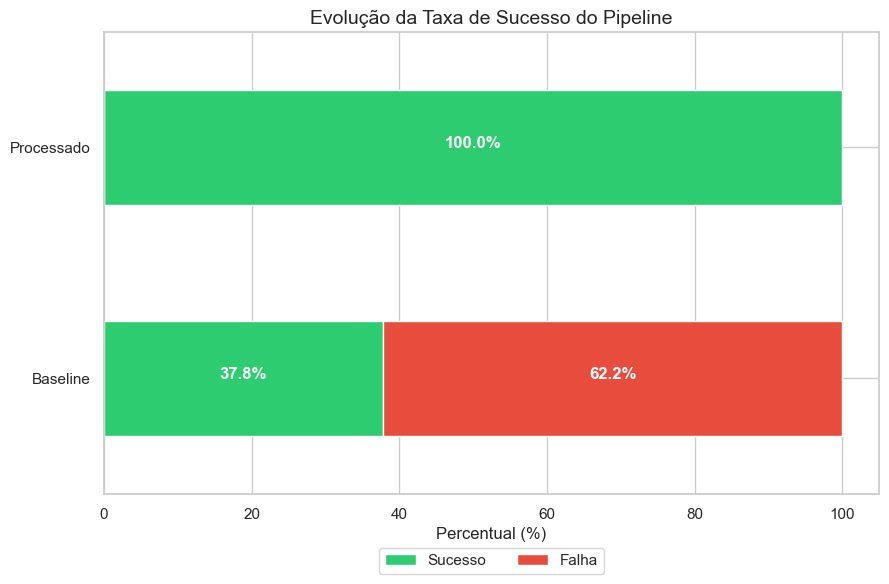

In [12]:
# Gráfico de antes e depois #

# Contar porcentagem de sucessos
def contar_taxa_sucessos(df):
    status = df['Execution_Status'].apply(lambda x: 'Sucesso' if x == 'Success' else 'Falha')
    return status.value_counts().reindex(['Sucesso', 'Falha'], fill_value=0)

stats_baseline = contar_taxa_sucessos(df_baseline)
stats_processed = contar_taxa_sucessos(df_processed)

# DataFrame para o gráfico
df_estabilidade = pd.DataFrame({
    'Baseline': stats_baseline,
    'Processado': stats_processed
}).T

# Calcular percentuais
df_perc = df_estabilidade.div(df_estabilidade.sum(axis=1), axis=0) * 100

ax = df_perc.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#2ecc71', '#e74c3c'])

# Adicionar os números absolutos dentro das barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (p.get_x() + width/2, p.get_y() + 0.25), 
                    ha='center', color='white', fontweight='bold')

plt.title('Evolução da Taxa de Sucesso do Pipeline', fontsize=14)
plt.xlabel('Percentual (%)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.show()

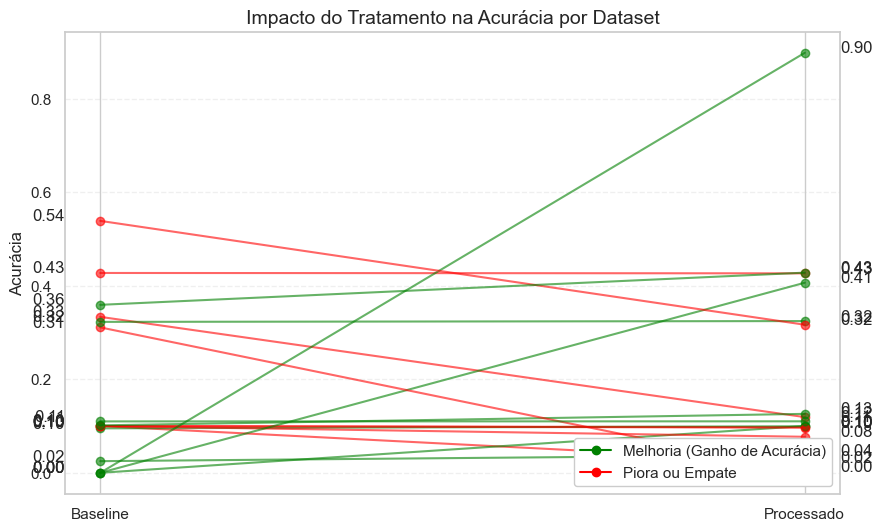

In [13]:
# Comparar Accuracy e F1 #
# Filtrar apenas execuções com sucesso
df_baseline = df_baseline[df_baseline['Execution_Status'] == 'Success']
df_processed = df_processed[df_processed['Execution_Status'] == 'Success']

# Merge dos dados com base no nome do Dataset
df_comparativo = pd.merge(
    df_baseline[['Dataset', 'Accuracy', 'F1_Macro', 'Training_Time_sec']], 
    df_processed[['Dataset', 'Accuracy', 'F1_Macro', 'Training_Time_sec']], 
    on='Dataset', 
    suffixes=('_Base', '_Proc')
)

# Calcular o ganho real (Delta)
df_comparativo['Delta_Accuracy'] = df_comparativo['Accuracy_Proc'] - df_comparativo['Accuracy_Base']
df_comparativo['Delta_F1'] = df_comparativo['F1_Macro_Proc'] - df_comparativo['F1_Macro_Base']

# Gráfico de antes e depois para todos os data sets
plt.figure(figsize=(10, 6))

# Loop para desenhar as linhas de cada dataset
for i, row in df_comparativo.iterrows():
    plt.plot(['Baseline', 'Processado'], [row['Accuracy_Base'], row['Accuracy_Proc']], 
             marker='o', color='green' if row['Delta_Accuracy'] > 0 else 'red', alpha=0.6)
    plt.text(-0.05, row['Accuracy_Base'], f"{row['Accuracy_Base']:.2f}", ha='right')
    plt.text(1.05, row['Accuracy_Proc'], f"{row['Accuracy_Proc']:.2f}", ha='left')

# --- ADIÇÃO DA LEGENDA AQUI ---
# Criamos duas "linhas invisíveis" apenas para forçar o matplotlib a criar a legenda
plt.plot([], [], color='green', marker='o', label='Melhoria (Ganho de Acurácia)')
plt.plot([], [], color='red', marker='o', label='Piora ou Empate')
plt.legend(loc='lower right', framealpha=1.0) # Posiciona a legenda no canto inferior direito
# ------------------------------

plt.title('Impacto do Tratamento na Acurácia por Dataset', fontsize=14)
plt.ylabel('Acurácia')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

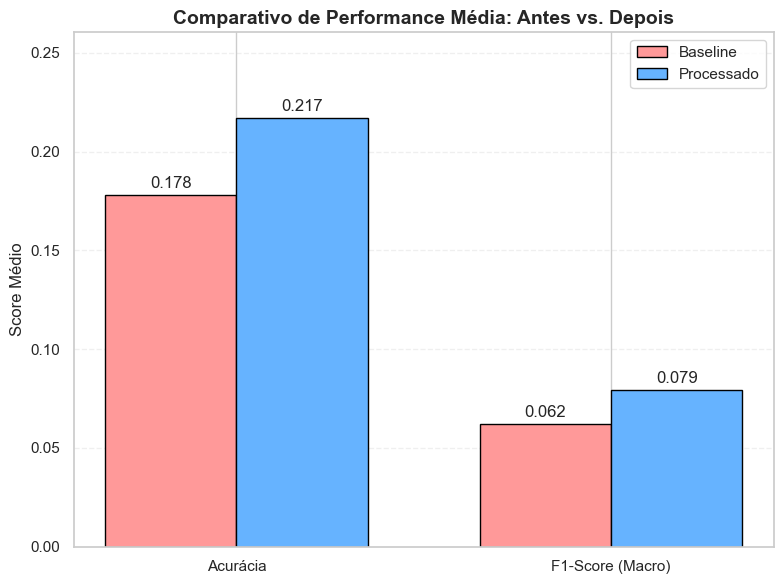

In [14]:
# Gráfico de Ganho Médio (Acurácia e F1) #

# Calcular as médias
metricas = ['Acurácia', 'F1-Score (Macro)']
medias_base = [df_comparativo['Accuracy_Base'].mean(), df_comparativo['F1_Macro_Base'].mean()]
medias_proc = [df_comparativo['Accuracy_Proc'].mean(), df_comparativo['F1_Macro_Proc'].mean()]

# Configuração das barras
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, medias_base, width, label='Baseline', color='#ff9999', edgecolor='black')
rects2 = ax.bar(x + width/2, medias_proc, width, label='Processado', color='#66b3ff', edgecolor='black')

# Adiciona rótulos de valores
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

# Textos
ax.set_ylabel('Score Médio')
ax.set_title('Comparativo de Performance Média: Antes vs. Depois', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()

plt.ylim(0, max(medias_proc) * 1.2) # Espaço para o rótulo
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Avaliação de melhorias no data set e possivel alteração do algoritimo 
##### Erros Identificados na Fase 1 (Baseline)
Durante os testes de benchmarking, foram detetados os seguintes problemas que impedem a execução correta em todos os datasets:

* **Incompatibilidade de Tipos (Strings):** O algoritmo falha ao processar colunas categóricas.
  * *Solução:* Aplicar One-Hot Encoding nas features e Label Encoding no alvo.
* **Instabilidade Numérica (Overflow):** Erros de cálculo exponencial em escalas de dados díspares.
  * *Solução:* Implementar a normalização de dados via padronização Z-Score antes do treino.
* **Valores Ausentes (NaN):** O modelo interrompe a execução ao encontrar dados em falta.
  * *Solução:* Aplicar imputação estatística (média/moda) em todos os sub-datasets.

#### *Ideia para a fase 2*

`Arquitetura: Regressão Logística Multiclasse (Softmax):`

Ativação (Softmax): As notas brutas passam pela função Softmax, sendo convertidas em uma distribuição de probabilidades onde a soma de todas as classes equivale a 100%.

Cálculo de Erro: Os rótulos originais são formatados em vetores binários (One-Hot Encoding). A função de custo Categorical Cross-Entropy mede a divergência entre a probabilidade prevista e o vetor real.

Otimização e Decisão: O gradiente do erro é calculado automaticamente para ajustar os pesos via Gradient Descent. Na classificação final, o algoritmo seleciona a categoria com a maior probabilidade (via operação argmax).


#### Fórmula Matemática

$$P(y=i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Onde:**

* **$P(y=i)$**: É a probabilidade de a amostra pertencer à classe $i$.
* **$e^{z_i}$**: É o número de Euler ($e \approx 2.718$) elevado ao valor (logit) da classe que estamos a calcular. O exponencial garante que o valor seja sempre positivo.
* **$\sum_{j=1}^{K} e^{z_j}$**: É a soma das exponenciais de todas as $K$ classes do modelo. Funciona como um normalizador para que o resultado final seja uma percentagem.
* **$z$**: É o resultado da combinação linear ($X \cdot \theta$) para cada classe.

TESTE DE HIPOSETE